In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
BASE = '/content/drive/MyDrive/LungTumour/'

def load_nodule(nodule_path):
    """Load CT slices and merge masks from multiple annotators."""
    image_folder = os.path.join(nodule_path, "images")
    mask_folders = [
        os.path.join(nodule_path, m)
        for m in os.listdir(nodule_path) if "mask" in m
    ]
    images, masks = [], []
    for img_file in sorted(os.listdir(image_folder)):
        img = cv2.imread(
            os.path.join(image_folder, img_file),
            cv2.IMREAD_GRAYSCALE
        )
        combined_mask = np.zeros_like(img)
        for mask_folder in mask_folders:
            mask_path = os.path.join(mask_folder, img_file)
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                combined_mask = np.maximum(combined_mask, mask)
        images.append(img)
        masks.append(combined_mask)
    return np.array(images), np.array(masks)


TARGET_DEPTH = 8

def pad_or_crop(volume):
    """Pad or crop volume to fixed depth of 8 slices."""
    d = volume.shape[0]
    if d >= TARGET_DEPTH:
        return volume[:TARGET_DEPTH]
    pad_before = (TARGET_DEPTH - d) // 2
    pad_after  = TARGET_DEPTH - d - pad_before
    return np.pad(volume,
                  ((pad_before, pad_after), (0,0), (0,0)),
                  mode='constant')

In [ ]:
dataset_path = "/content/dataset/LIDC-IDRI-slices"

if not os.path.exists(dataset_path):
    !unzip -q "{BASE}dataset.zip" -d /content/dataset
    print("Dataset extracted ✓")

all_volumes, all_masks = [], []

for patient in sorted(os.listdir(dataset_path)):
    patient_path = os.path.join(dataset_path, patient)
    if not os.path.isdir(patient_path):
        continue
    for nodule in sorted(os.listdir(patient_path)):
        nodule_path = os.path.join(patient_path, nodule)
        if not os.path.isdir(nodule_path):
            continue
        try:
            imgs, msks = load_nodule(nodule_path)

            # Resize to 128x128
            imgs = np.array([cv2.resize(i, (128,128)) for i in imgs])
            msks = np.array([cv2.resize(m, (128,128)) for m in msks])

            # Normalize images to [0,1] — masks stay binary
            imgs = imgs.astype(np.float32) / 255.0

            all_volumes.append(imgs)
            all_masks.append(msks)
        except Exception as e:
            print(f"Skipped {nodule_path}: {e}")

print(f"Total nodules loaded: {len(all_volumes)}")

Dataset extracted ✓
Total nodules loaded: 2630


In [ ]:
import gc

# Build arrays with explicit padding applied
print("Building arrays...")

X_list, Y_list = [], []

for v, m in zip(all_volumes, all_masks):
    v_padded = pad_or_crop(v)  # ensure (8, 128, 128)
    m_padded = pad_or_crop(m)  # ensure (8, 128, 128)

    # Skip if shape is wrong after padding
    if v_padded.shape == (8, 128, 128) and m_padded.shape == (8, 128, 128):
        X_list.append(v_padded)
        Y_list.append(m_padded)
    else:
        print(f"Skipped — shape: {v_padded.shape}")

print(f"Valid samples: {len(X_list)}")

X = np.array(X_list)[..., np.newaxis]  # (N, 8, 128, 128, 1)
Y = np.array(Y_list)[..., np.newaxis]
Y = (Y > 0).astype(np.float32)

# Free lists
del X_list, Y_list, all_volumes, all_masks
gc.collect()

print("X shape:", X.shape)
print("X max  :", X.max())      # should be ~1.0
print("X min  :", X.min())      # should be 0.0
print("Y unique:", np.unique(Y)) # should be [0. 1.]

Building arrays...
Valid samples: 2630
X shape: (2630, 8, 128, 128, 1)
X max  : 1.0
X min  : 0.0
Y unique: [0. 1.]


In [ ]:
from sklearn.model_selection import train_test_split
import gc

# Step 1 — separate 15% for test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42
)

# Step 2 — split remaining into train + val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

# Save all splits
np.save(BASE + 'X_train.npy', X_train)
np.save(BASE + 'X_val.npy',   X_val)
np.save(BASE + 'y_train.npy', y_train)
np.save(BASE + 'y_val.npy',   y_val)
np.save(BASE + 'X_test.npy',  X_test)
np.save(BASE + 'y_test.npy',  y_test)
print("All splits saved ✓")

# Clear RAM
del X, Y, X_temp, y_temp, X_train, y_train, X_test, y_test
gc.collect()

# Keep only val in RAM
X_val = np.load(BASE + 'X_val.npy')
y_val = np.load(BASE + 'y_val.npy')
train_size = np.load(BASE + 'X_train.npy', mmap_mode='r').shape[0]

print(f"X_val : {X_val.shape}")
print(f"Train size: {train_size}")
print("RAM cleared — only val in memory ✓")

Train : 1841 samples
Val   : 394 samples
Test  : 395 samples
All splits saved ✓
X_val : (394, 8, 128, 128, 1)
Train size: 1841
RAM cleared — only val in memory ✓


In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(y_true, y_pred)
    )
    dice = 1 - dice_coefficient(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice

print("Loss functions defined ✓")


Loss functions defined ✓


In [ ]:
from tensorflow.keras import layers, regularizers

L2 = 1e-4  # L2 regularization factor

def conv_block(x, filters, dropout_rate=0.2):
    """Conv3D × 2 + BN + ReLU + SpatialDropout + L2 regularization."""
    for _ in range(2):
        x = layers.Conv3D(
            filters, (3,3,3),
            padding='same',
            kernel_regularizer=regularizers.l2(L2)
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    x = layers.SpatialDropout3D(dropout_rate)(x)
    return x


def attention_gate(x, g, filters):
    """Soft attention gate — suppresses irrelevant background regions.

    x : skip connection from encoder (high resolution)
    g : gating signal from decoder (low resolution, semantic)
    """
    theta_x = layers.Conv3D(
        filters, (1,1,1), padding='same',
        kernel_regularizer=regularizers.l2(L2)
    )(x)
    phi_g = layers.Conv3D(
        filters, (1,1,1), padding='same',
        kernel_regularizer=regularizers.l2(L2)
    )(g)
    phi_g   = layers.UpSampling3D(size=(1,2,2))(phi_g)
    add     = layers.Add()([theta_x, phi_g])
    act     = layers.Activation('relu')(add)
    psi     = layers.Conv3D(1, (1,1,1), padding='same')(act)
    sigmoid = layers.Activation('sigmoid')(psi)
    return layers.Multiply()([x, sigmoid])


def build_attention_unet(input_shape=(8, 128, 128, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 16, dropout_rate=0.1)
    p1 = layers.MaxPooling3D((1, 2, 2))(c1)

    c2 = conv_block(p1, 32, dropout_rate=0.1)
    p2 = layers.MaxPooling3D((1, 2, 2))(c2)

    c3 = conv_block(p2, 64, dropout_rate=0.2)
    p3 = layers.MaxPooling3D((1, 2, 2))(c3)

    # Bottleneck — highest dropout here
    c4 = conv_block(p3, 128, dropout_rate=0.3)

    # Decoder with attention gates
    u1 = layers.UpSampling3D((1, 2, 2))(c4)
    a1 = attention_gate(c3, c4, 64)
    u1 = layers.Concatenate()([u1, a1])
    c5 = conv_block(u1, 64, dropout_rate=0.2)

    u2 = layers.UpSampling3D((1, 2, 2))(c5)
    a2 = attention_gate(c2, c5, 32)
    u2 = layers.Concatenate()([u2, a2])
    c6 = conv_block(u2, 32, dropout_rate=0.1)

    u3 = layers.UpSampling3D((1, 2, 2))(c6)
    a3 = attention_gate(c1, c6, 16)
    u3 = layers.Concatenate()([u3, a3])
    c7 = conv_block(u3, 16, dropout_rate=0.1)

    outputs = layers.Conv3D(
        1, (1,1,1), activation='sigmoid',
        kernel_regularizer=regularizers.l2(L2)
    )(c7)

    return tf.keras.Model(inputs, outputs, name='Attention_UNet_3D')


model = build_attention_unet()
model.summary()

Model: "Attention_UNet_3D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_24 (Conv3D)  │ (None, 8, 128,    │        448 │ input_layer_1[0]… │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128,    │         64 │ conv3d_24[0][0]   │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_25 (Conv3D)  │ (None, 8, 128,    │      6,928 │ activation_20[0]… │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128,    │         64 │ conv3d_25[0][0]   │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d_7 │ (None, 8, 128,    │          0 │ activation_21[0]… │
│ (SpatialDropout3D)  │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 8, 64, 64, │          0 │ spatial_dropout3… │
│ (MaxPooling3D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_26 (Conv3D)  │ (None, 8, 64, 64, │     13,856 │ max_pooling3d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        128 │ conv3d_26[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_27 (Conv3D)  │ (None, 8, 64, 64, │     27,680 │ activation_22[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        128 │ conv3d_27[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d_8 │ (None, 8, 64, 64, │          0 │ activation_23[0]… │
│ (SpatialDropout3D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_4     │ (None, 8, 32, 32, │          0 │ spatial_dropout3

 Total params: 1,478,868 (5.64 MB)

 Trainable params: 1,477,460 (5.64 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
import shutil, os

LOCAL = '/content/lung_data/'
os.makedirs(LOCAL, exist_ok=True)

print("Copying data from Drive to local...")
for f in ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy']:
    if not os.path.exists(LOCAL + f):
        shutil.copy(BASE + f, LOCAL + f)
        print(f"  ✅ {f} copied")
    else:
        print(f"  ⚡ {f} already exists")

print("All done ✅")

Copying data from Drive to local...
  ✅ X_train.npy copied
  ✅ y_train.npy copied
  ✅ X_val.npy copied
  ✅ y_val.npy copied
All done ✅


In [ ]:
import tensorflow as tf
import numpy as np

# Full load into RAM
X_train_arr = np.load(LOCAL + 'X_train.npy')
y_train_arr = np.load(LOCAL + 'y_train.npy')
print(f"Train loaded ✅ {X_train_arr.shape}")

# Augmentation in tf.data (runs in parallel, prefetched)
def augment_tf(volume, mask):
    # Horizontal flip
    if tf.random.uniform(()) > 0.5:
        volume = tf.reverse(volume, axis=[2])
        mask   = tf.reverse(mask,   axis=[2])
    # Vertical flip
    if tf.random.uniform(()) > 0.5:
        volume = tf.reverse(volume, axis=[1])
        mask   = tf.reverse(mask,   axis=[1])
    # Gaussian noise
    if tf.random.uniform(()) > 0.5:
        noise  = tf.random.normal(tf.shape(volume), mean=0.0, stddev=0.02)
        volume = tf.clip_by_value(volume + noise, 0.0, 1.0)
    # Brightness
    if tf.random.uniform(()) > 0.5:
        factor = tf.random.uniform((), 0.9, 1.1)
        volume = tf.clip_by_value(volume * factor, 0.0, 1.0)
    return volume, mask

BATCH_SIZE = 4
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train_arr, y_train_arr))
train_ds = (train_ds
    .shuffle(buffer_size=500, reshuffle_each_iteration=True)
    .map(augment_tf, num_parallel_calls=AUTOTUNE)   # parallel augmentation
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)                              # GPU never waits
)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = (val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

steps_per_epoch = train_size // BATCH_SIZE
print(f"Steps/epoch: {steps_per_epoch} ✅")
print("tf.data pipeline ready ✓")

Train loaded ✅ (1841, 8, 128, 128, 1)
Steps/epoch: 460 ✅
tf.data pipeline ready ✓


In [ ]:
import time

# Test 1 — pure batch fetch speed
print("=== Test 1: tf.data batch speed ===")
iterator = iter(train_ds)
times = []
for i in range(10):
    t0 = time.time()
    xb, yb = next(iterator)
    times.append(time.time() - t0)
print(f"Avg batch fetch: {np.mean(times)*1000:.1f}ms")

# Test 2 — pure forward pass speed (no data loading)
print("\n=== Test 2: forward pass speed ===")
xb_gpu = tf.constant(X_train_arr[:4])
times = []
for i in range(10):
    t0 = time.time()
    _ = model(xb_gpu, training=False)
    times.append(time.time() - t0)
print(f"Avg forward pass: {np.mean(times)*1000:.1f}ms")

# Test 3 — single train step speed
print("\n=== Test 3: single train step ===")
xb, yb = next(iter(train_ds))
times = []
for i in range(10):
    t0 = time.time()
    model.train_on_batch(xb, yb)
    times.append(time.time() - t0)
print(f"Avg train step: {np.mean(times)*1000:.1f}ms")

=== Test 1: tf.data batch speed ===
Avg batch fetch: 8.7ms

=== Test 2: forward pass speed ===
Avg forward pass: 338.9ms

=== Test 3: single train step ===
Avg train step: 2213.4ms


In [ ]:
# Add to Cell 10 before model.fit — loads best weights if they exist
import os
if os.path.exists(BASE + 'attention_unet_best.h5'):
    model.load_weights(BASE + 'attention_unet_best.h5')
    print("Resumed from checkpoint ✅")
else:
    print("Starting fresh ✅")

Resumed from checkpoint ✅


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        BASE + 'attention_unet_best.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=4,
        mode='max',
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        BASE + 'attention_unet_log.csv'
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

print(f"Training complete ✓")
print(f"Best Val Dice: {max(history.history['val_dice_coefficient']):.4f}")

Epoch 1/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - dice_coefficient: 0.1957 - loss: 0.4561
Epoch 1: val_dice_coefficient improved from None to 0.27143, saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 189s 344ms/step - dice_coefficient: 0.2185 - loss: 0.4437 - val_dice_coefficient: 0.2714 - val_loss: 0.4257 - learning_rate: 3.0000e-04
Epoch 2/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - dice_coefficient: 0.3216 - loss: 0.3886
Epoch 2: val_dice_coefficient improved from 0.27143 to 0.41811, saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 136s 294ms/step - dice_coefficient: 0.3343 - loss: 0.3825 - val_dice_coefficient: 0.4181 - val_loss: 0.3403 - learning_rate: 3.0000e-04
Epoch 3/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.4017 - loss: 0.3489
Epoch 3: val_dice_coefficient improved from 0.41811 to 0.42802, saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 135s 294ms/step - dice_coefficient: 0.3977 - loss: 0.3524 - val_dice_coefficient: 0.4280 - val_loss: 0.3341 - learning_rate: 3.0000e-04
Epoch 4/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.4797 - loss: 0.3111
Epoch 4: val_dice_coefficient improved from 0.42802 to 0.52284, saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 136s 294ms/step - dice_coefficient: 0.4711 - loss: 0.3161 - val_dice_coefficient: 0.5228 - val_loss: 0.2895 - learning_rate: 3.0000e-04
Epoch 5/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.5035 - loss: 0.3014
Epoch 5: val_dice_coefficient did not improve from 0.52284
461/461 ━━━━━━━━━━━━━━━━━━━━ 133s 289ms/step - dice_coefficient: 0.5122 - loss: 0.2966 - val_dice_coefficient: 0.5192 - val_loss: 0.2914 - learning_rate: 3.0000e-04
Epoch 6/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - dice_coefficient: 0.5555 - loss: 0.2744
Epoch 6: val_dice_coefficient improved from 0.52284 to 0.53522, saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5


...


Epoch 15: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 135s 294ms/step - dice_coefficient: 0.6928 - loss: 0.2032 - val_dice_coefficient: 0.6957 - val_loss: 0.1995 - learning_rate: 3.0000e-04
Epoch 16/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.6839 - loss: 0.2077
Epoch 16: val_dice_coefficient did not improve from 0.69575
461/461 ━━━━━━━━━━━━━━━━━━━━ 133s 288ms/step - dice_coefficient: 0.6885 - loss: 0.2052 - val_dice_coefficient: 0.6854 - val_loss: 0.2055 - learning_rate: 3.0000e-04
Epoch 17/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.6834 - loss: 0.2079
Epoch 17: val_dice_coefficient did not improve from 0.69575
461/461 ━━━━━━━━━━━━━━━━━━━━ 133s 289ms/step - dice_coefficient: 0.6830 - loss: 0.2081 - val_dice_coefficient: 0.5592 - val_loss: 0.2734 - learning_rate: 3.0000e-04
Epoch 18/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.6888 - loss: 0.2064
E


Epoch 19: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 136s 295ms/step - dice_coefficient: 0.7203 - loss: 0.1891 - val_dice_coefficient: 0.7118 - val_loss: 0.1918 - learning_rate: 3.0000e-04
Epoch 20/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.7160 - loss: 0.1908
Epoch 20: val_dice_coefficient did not improve from 0.71177
461/461 ━━━━━━━━━━━━━━━━━━━━ 133s 289ms/step - dice_coefficient: 0.7079 - loss: 0.1951 - val_dice_coefficient: 0.6995 - val_loss: 0.1984 - learning_rate: 3.0000e-04
Epoch 21/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - dice_coefficient: 0.7166 - loss: 0.1911
Epoch 21: val_dice_coefficient did not improve from 0.71177
461/461 ━━━━━━━━━━━━━━━━━━━━ 143s 290ms/step - dice_coefficient: 0.7180 - loss: 0.1895 - val_dice_coefficient: 0.7024 - val_loss: 0.1963 - learning_rate: 3.0000e-04
Epoch 22/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - dice_coefficient: 0.7203 - loss: 0.1889
E


Epoch 24: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 134s 292ms/step - dice_coefficient: 0.7357 - loss: 0.1789 - val_dice_coefficient: 0.7260 - val_loss: 0.1818 - learning_rate: 1.5000e-04
Epoch 25/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.7283 - loss: 0.1818
Epoch 25: val_dice_coefficient improved from 0.72605 to 0.73783, saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5



Epoch 25: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 136s 296ms/step - dice_coefficient: 0.7379 - loss: 0.1765 - val_dice_coefficient: 0.7378 - val_loss: 0.1740 - learning_rate: 1.5000e-04
Epoch 26/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.7473 - loss: 0.1699
Epoch 26: val_dice_coefficient did not improve from 0.73783
461/461 ━━━━━━━━━━━━━━━━━━━━ 133s 289ms/step - dice_coefficient: 0.7446 - loss: 0.1715 - val_dice_coefficient: 0.7344 - val_loss: 0.1750 - learning_rate: 1.5000e-04
Epoch 27/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.7361 - loss: 0.1746
Epoch 27: val_dice_coefficient did not improve from 0.73783
461/461 ━━━━━━━━━━━━━━━━━━━━ 133s 289ms/step - dice_coefficient: 0.7423 - loss: 0.1713 - val_dice_coefficient: 0.7029 - val_loss: 0.1911 - learning_rate: 1.5000e-04
Epoch 28/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - dice_coefficient: 0.7495 - loss: 0.1667
E


Epoch 29: finished saving model to /content/drive/MyDrive/LungTumour/attention_unet_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 135s 293ms/step - dice_coefficient: 0.7587 - loss: 0.1612 - val_dice_coefficient: 0.7429 - val_loss: 0.1678 - learning_rate: 1.5000e-04
Epoch 30/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coefficient: 0.7480 - loss: 0.1659
Epoch 30: val_dice_coefficient did not improve from 0.74286
461/461 ━━━━━━━━━━━━━━━━━━━━ 133s 289ms/step - dice_coefficient: 0.7448 - loss: 0.1678 - val_dice_coefficient: 0.7386 - val_loss: 0.1700 - learning_rate: 1.5000e-04
Restoring model weights from the end of the best epoch: 29.
Training complete ✓
Best Val Dice: 0.7429


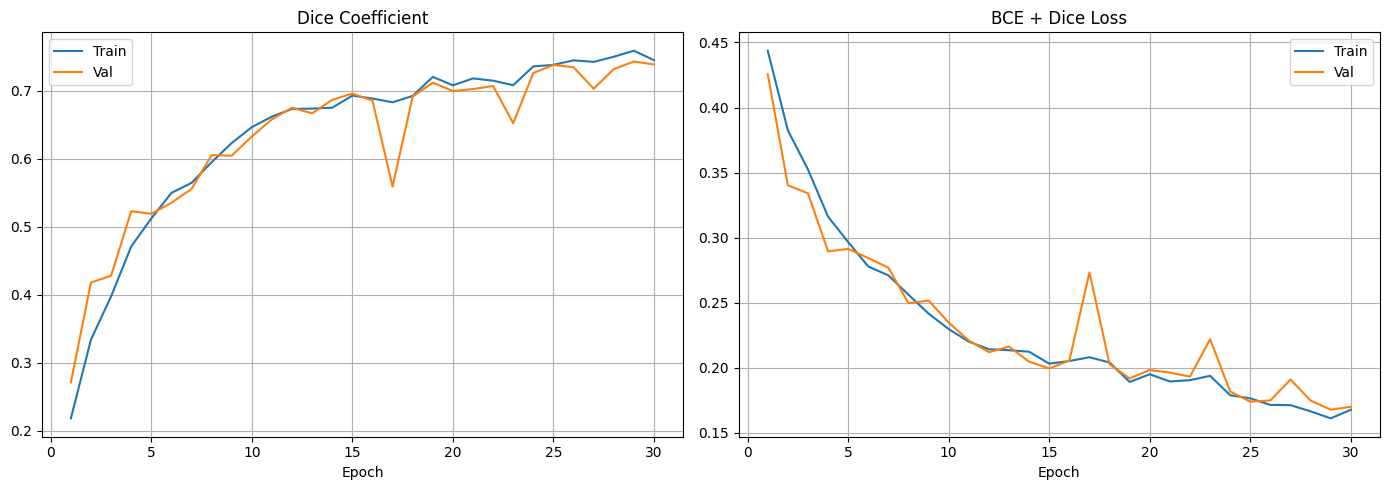

In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history.history['dice_coefficient'], label='Train')
axes[0].plot(epochs, history.history['val_dice_coefficient'], label='Val')
axes[0].set_title('Dice Coefficient')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history.history['loss'], label='Train')
axes[1].plot(epochs, history.history['val_loss'], label='Val')
axes[1].set_title('BCE + Dice Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE + 'attention_unet_training_curves.png',
            dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
y_pred_val     = model.predict(X_val, batch_size=2, verbose=1)
y_pred_val_bin = (y_pred_val > 0.5).astype(np.float32)

def compute_metrics(y_true, y_pred_bin):
    results = []
    for i in range(len(y_true)):
        gt   = y_true[i].flatten()
        pred = y_pred_bin[i].flatten()
        TP = np.sum(gt * pred)
        FP = np.sum((1 - gt) * pred)
        FN = np.sum(gt * (1 - pred))
        TN = np.sum((1 - gt) * (1 - pred))
        results.append({
            'dice'        : (2*TP + 1e-6) / (2*TP + FP + FN + 1e-6),
            'iou'         : (TP + 1e-6) / (TP + FP + FN + 1e-6),
            'sensitivity' : (TP + 1e-6) / (TP + FN + 1e-6),
            'precision'   : (TP + 1e-6) / (TP + FP + 1e-6),
            'specificity' : (TN + 1e-6) / (TN + FP + 1e-6)
        })
    return results

results_val = compute_metrics(y_val, y_pred_val_bin)
print("\n===== Val Sanity Check (not final metric) =====")
for m in ['dice','iou','sensitivity','precision','specificity']:
    vals = [r[m] for r in results_val]
    print(f"{m:>12s}: {np.mean(vals):.4f}")

197/197 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step

===== Val Sanity Check (not final metric) =====
        dice: 0.7027
         iou: 0.5827
 sensitivity: 0.6998
   precision: 0.8084
 specificity: 0.9993


In [ ]:
# Load test set
X_test = np.load(BASE + 'X_test.npy')
y_test  = np.load(BASE + 'y_test.npy')
print(f"Test set: {X_test.shape}")

# Predict
y_pred_test     = model.predict(X_test, batch_size=2, verbose=1)
y_pred_test_bin = (y_pred_test > 0.5).astype(np.float32)

# Metrics
results_test = compute_metrics(y_test, y_pred_test_bin)
print("\n===== FINAL TEST SET METRICS =====")
for m in ['dice','iou','sensitivity','precision','specificity']:
    vals = [r[m] for r in results_test]
    print(f"{m:>12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Test set: (395, 8, 128, 128, 1)
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step

===== FINAL TEST SET METRICS =====
        dice: 0.7234 ± 0.2219
         iou: 0.6031 ± 0.2132
 sensitivity: 0.7168 ± 0.2449
   precision: 0.8229 ± 0.1827
 specificity: 0.9994 ± 0.0015


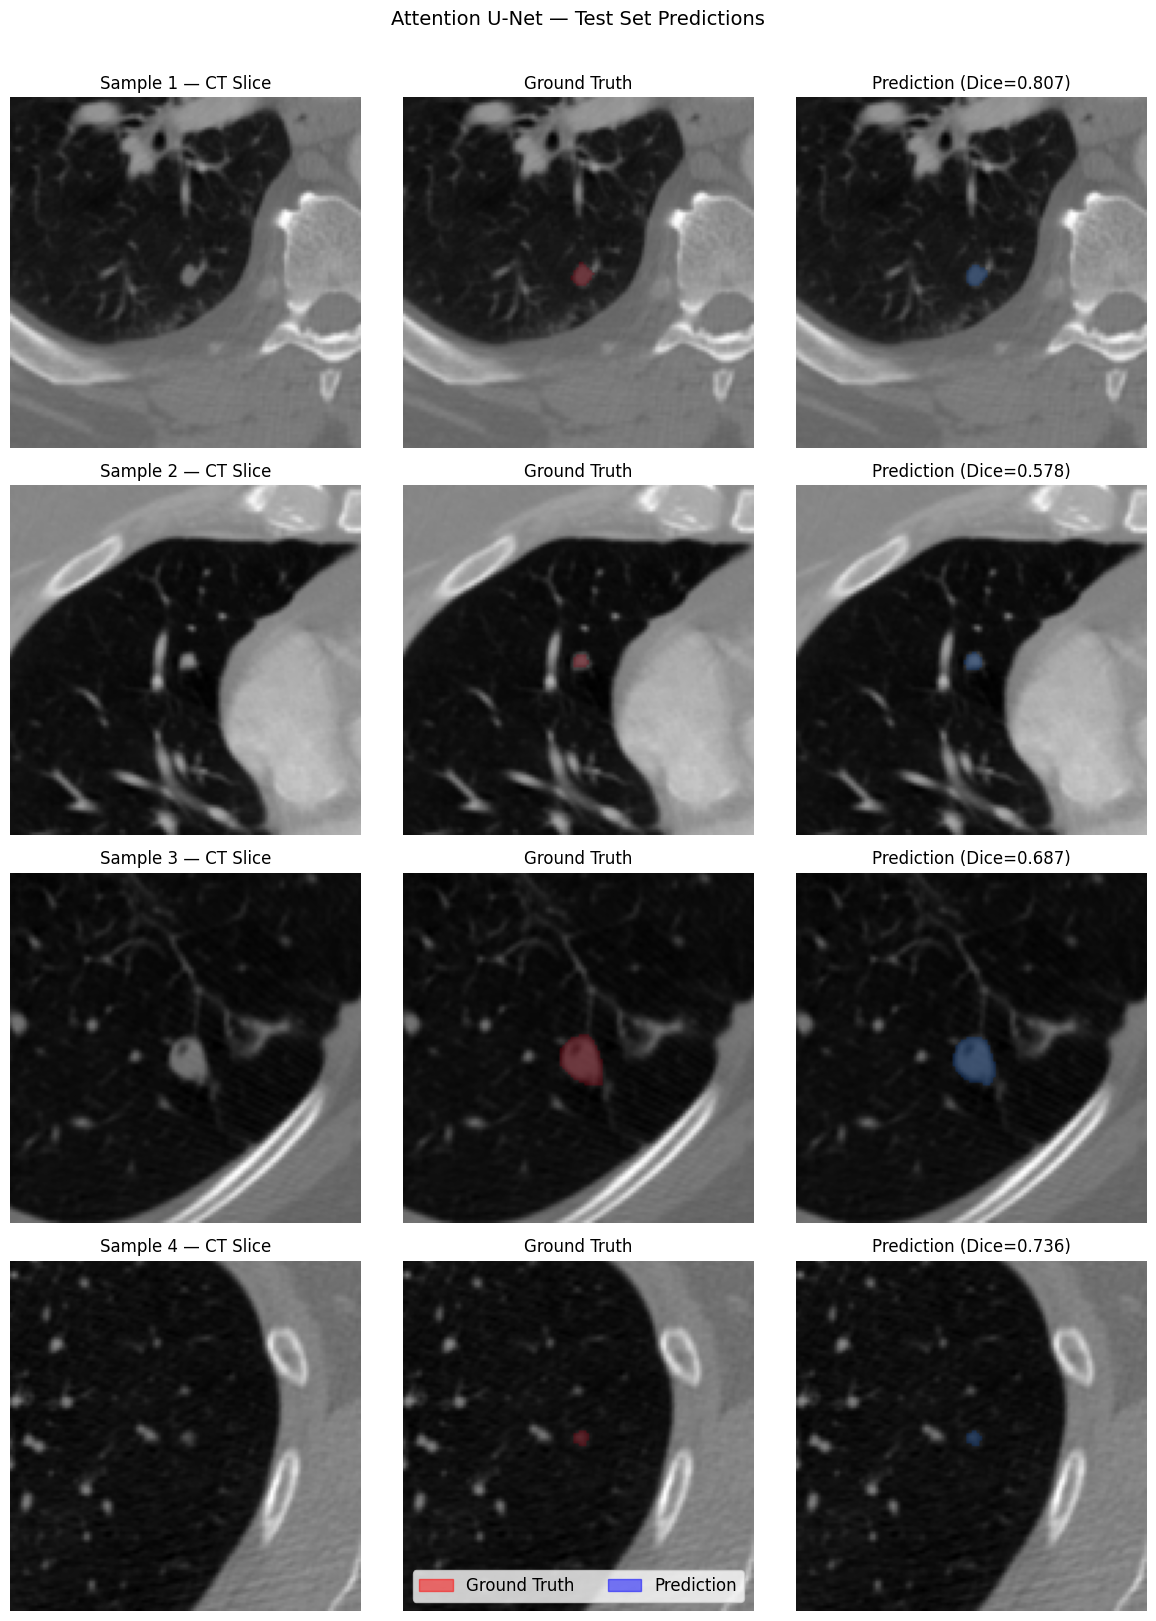

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualise_predictions(X, y_true, y_pred_bin, num_samples=4, slice_idx=4):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

    for i in range(num_samples):
        img  = X[i, slice_idx, :, :, 0]
        gt   = y_true[i, slice_idx, :, :, 0]
        pred = y_pred_bin[i, slice_idx, :, :, 0]

        # CT image
        axes[i,0].imshow(img, cmap='gray')
        axes[i,0].set_title(f'Sample {i+1} — CT Slice')
        axes[i,0].axis('off')

        # Ground truth overlay
        axes[i,1].imshow(img, cmap='gray')
        axes[i,1].imshow(np.ma.masked_where(gt == 0, gt),
                         cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[i,1].set_title('Ground Truth')
        axes[i,1].axis('off')

        # Prediction overlay
        axes[i,2].imshow(img, cmap='gray')
        axes[i,2].imshow(np.ma.masked_where(pred == 0, pred),
                         cmap='Blues', alpha=0.5, vmin=0, vmax=1)
        dice = results_test[i]['dice']
        axes[i,2].set_title(f'Prediction (Dice={dice:.3f})')
        axes[i,2].axis('off')

    red_patch  = mpatches.Patch(color='red',  alpha=0.5, label='Ground Truth')
    blue_patch = mpatches.Patch(color='blue', alpha=0.5, label='Prediction')
    fig.legend(handles=[red_patch, blue_patch], loc='lower center',
               ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.01))

    plt.suptitle('Attention U-Net — Test Set Predictions', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(BASE + 'test_predictions.png', dpi=100, bbox_inches='tight')
    plt.show()

# Show 4 random samples
rand_idx = np.random.choice(len(X_test), 4, replace=False)
visualise_predictions(
    X_test[rand_idx],
    y_test[rand_idx],
    y_pred_test_bin[rand_idx]
)